# Modelisation Step of Anomaly Detection Project: Deep Learning Part

### Initial model plan (with CNN Classifiers): 
1. Train a CNN for multi-class classification of object types (see if it achieves better performance than random forests for texture types)
2. Train a CNN for multi-class classification of anomaly type for single type of object
3. See if data augmentation techniques for minority anomaly classes improves performance
4. If unable to perform multi-class anomaly classification, recast to binary classification (anomaly or not)
5. Look into autoencoders as an alternative for anomaly detection?
6. Look into transfer learning for similar anomaly types? e.g. texture types often having similar (glue, hole, etc)


In [5]:
# Library imports

from pathlib import Path
import os
import cv2
import numpy as np

# Imports for visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Imports for ML
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Imports for CNNs

# Imports for building the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

# Imports for image transformations
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast 
from tensorflow.keras.layers import RandomTranslation

# Importing the image_dataset_from_directory utility from Keras
from keras.utils import image_dataset_from_directory

# Importing loss function
from tensorflow.keras.losses import CategoricalCrossentropy


/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [21]:
# Functions

def plot_training(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]
    
    plt.figure(figsize=(20, 8))
    
    # Plot the MSE loss
    plt.subplot(121)
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.title('Model Loss per Epoch (MSE)')
    plt.ylabel('Loss (MSE)')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    # Plot the Mean Absolute Error (MAE)
    plt.subplot(122)
    plt.plot(train_acc)
    plt.plot(val_acc)
    plt.title('Accuracy per Epoch')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    plt.show()


def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)


def plot_cm(y_true, y_pred):
    plt.figure(figsize=(10, 10))  # Create a large figure for the confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')  # Compute the normalized confusion matrix
    sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")  # Plot the confusion matrix as a heatmap
    plt.show()
   

In [22]:
# Generic CNN model definition

# Define the model input
inputs = Input(shape=(None, None, 3))

# Image transformations: resizing, normalization
x = Resizing(100, 100)(inputs)    # Resize the images to 100x100 pixels
x = Rescaling(1./255)(x)        # Normalize the pixel values to be between 0 and 1

# Adding the convolutional layer
x = Conv2D(filters=32, 
           kernel_size=(3, 3), 
           activation="relu",
           padding="valid")(x)

# Adding the pooling layer to reduce the size of the data
x = MaxPooling2D(pool_size=(2, 2), padding='valid')(x)

# Adding a dropout layer to prevent overfitting
x = Dropout(0.3)(x)

# Flattening the data to pass it to the dense layer
x = Flatten()(x)

# Dense layer for making the prediction
outputs = Dense(
    units=15,
    activation='softmax')(x) 

# Define the model with the specified inputs and outputs
model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])


## CNN for multi-class object classification

In [25]:
# Defining datasets (MVTec 'train' 'good' only)

data_dir = "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects/"  

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=32               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=32
)


Found 3629 files belonging to 15 classes.
Using 2904 files for training.
Found 3629 files belonging to 15 classes.
Using 725 files for validation.


In [26]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())


Number of batch in train_ds: 91
Number of batch in val_ds: 23


In [27]:
categories = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects/").iterdir() if p.is_dir()]

print('Object type to label mapping:')
for label, obj in enumerate(categories):
    print(f'{label}: {obj}')
    

Object type to label mapping:
0: bottle
1: cable
2: capsule
3: carpet
4: grid
5: hazelnut
6: leather
7: metal_nut
8: pill
9: screw
10: tile
11: toothbrush
12: transistor
13: wood
14: zipper


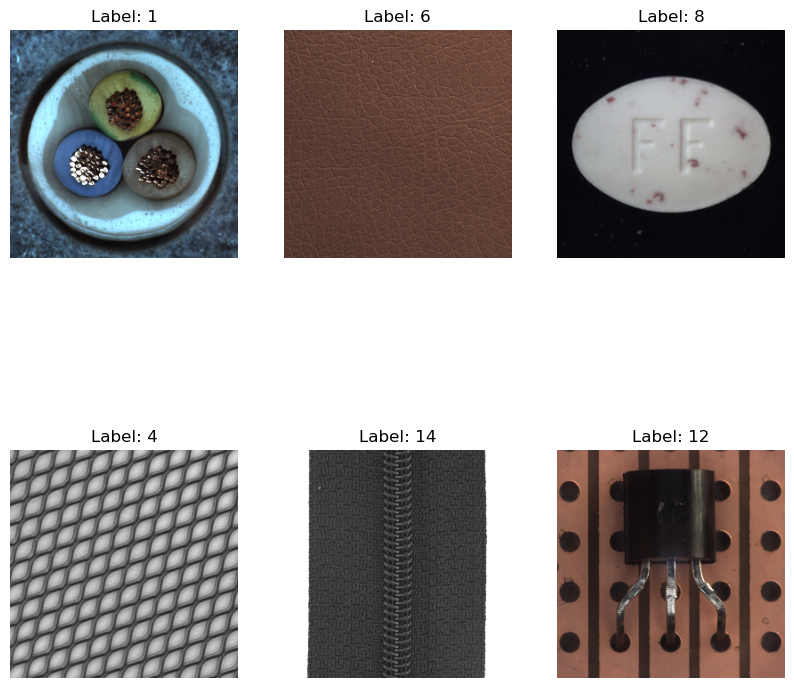

In [28]:
# Define the number of images to display
number_of_images = 6

# Create a figure for displaying
plt.figure(figsize=(10,10))

# Get a batch of images from train_ds
for images, labels in train_ds.take(1):
    # Display the images from the batch
    for i in range(number_of_images):
        ax = plt.subplot(2, 3, i + 1) 
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert the image to integer for display
        plt.axis("off") 
        plt.title(f"Label: {labels[i].numpy()}")  # Display the label of the image (+18 since our age data starts at 18 and labels start at 0)

# Show the images
plt.show()


In [44]:
# Train generic model defined at top of notebook

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


In [45]:
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 76832)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │     1,152,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153,391 (4.40 MB)

 Trainable params: 1,153,391 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

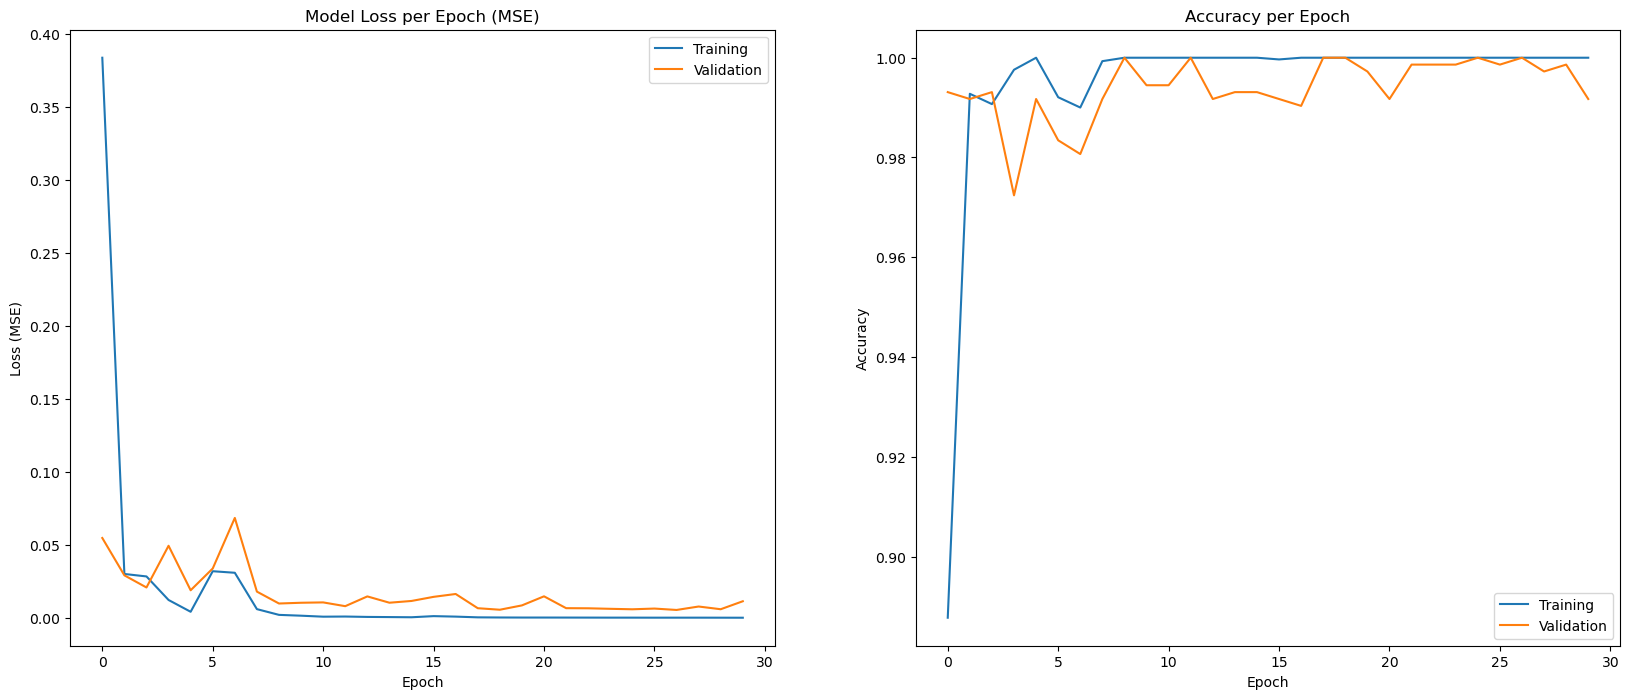

In [30]:
# Visualise model training (evolution of loss function and accuracy per epoch)

plot_training(model_history)


In [31]:
# Save model architecture and weights

model.save('cnn_obj_classifier.keras')
model.save_weights('cnn_obj_classifier.weights.h5')


In [32]:
# Assess model performance with holdout data (MVTec 'test' 'good' only)

test_ds = image_dataset_from_directory(
    "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_good/",
    seed=24,
    batch_size=16,
)  

y_true, y_pred = get_predictions_and_labels(test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


Found 467 files belonging to 15 classes.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        58
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        21
           5       1.00      1.00      1.00        40
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00        22
           8       1.00      1.00      1.00        26
           9       1.00      1.00      1.00        41
          10       1.00      1.00      1.00        33
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00        60
          13       1.00      1.00      1.00        19
          14       1.00      1.00      1.00        32

    accuracy                           1.00       467
   macro avg       1.00      1.00      

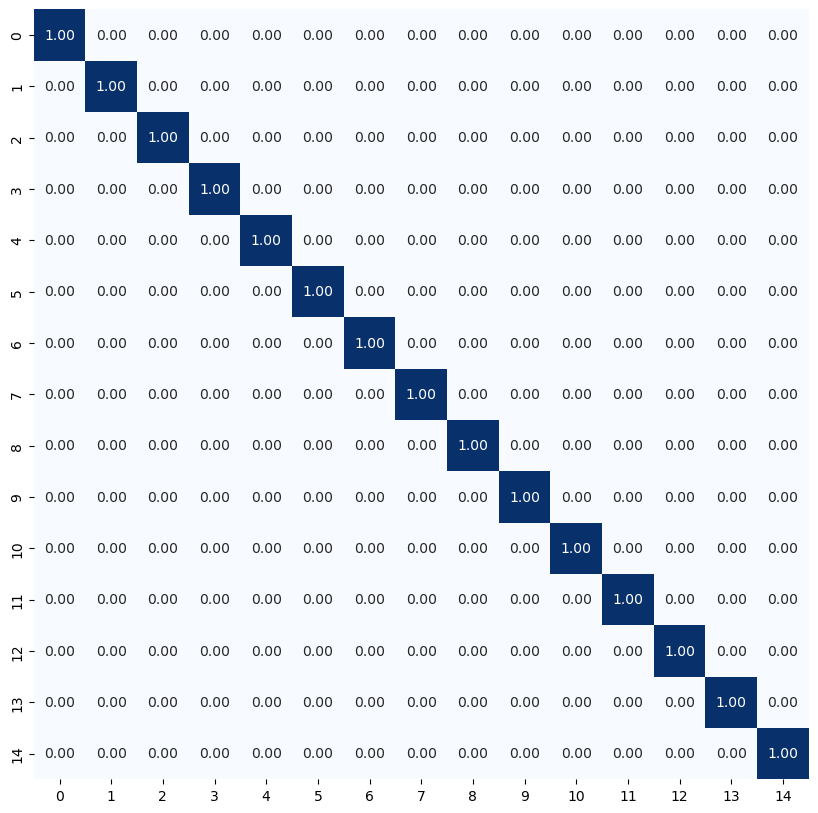

In [35]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


In [36]:
# Assess model performance with holdout data (test good and all anomaly types)

test_ds = image_dataset_from_directory(
    "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_all/",
    seed=24,
    batch_size=32,
)  

y_true, y_pred = get_predictions_and_labels(test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


Found 1725 files belonging to 15 classes.


2026-01-26 18:06:52.668640: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25165824 bytes after encountering the first element of size 25165824 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-01-26 18:07:01.295788: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25165824 bytes after encountering the first element of size 25165824 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       1.00      1.00      1.00       117
           4       0.99      0.90      0.94        78
           5       1.00      1.00      1.00       110
           6       0.99      1.00      1.00       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       1.00      1.00      1.00       160
          10       0.94      0.99      0.96       117
          11       1.00      1.00      1.00        42
          12       1.00      0.99      0.99       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           0.99      1725
   macro avg       0.99      0.99      0.99      1725
weighted avg       0.99   

2026-01-26 18:07:20.695312: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


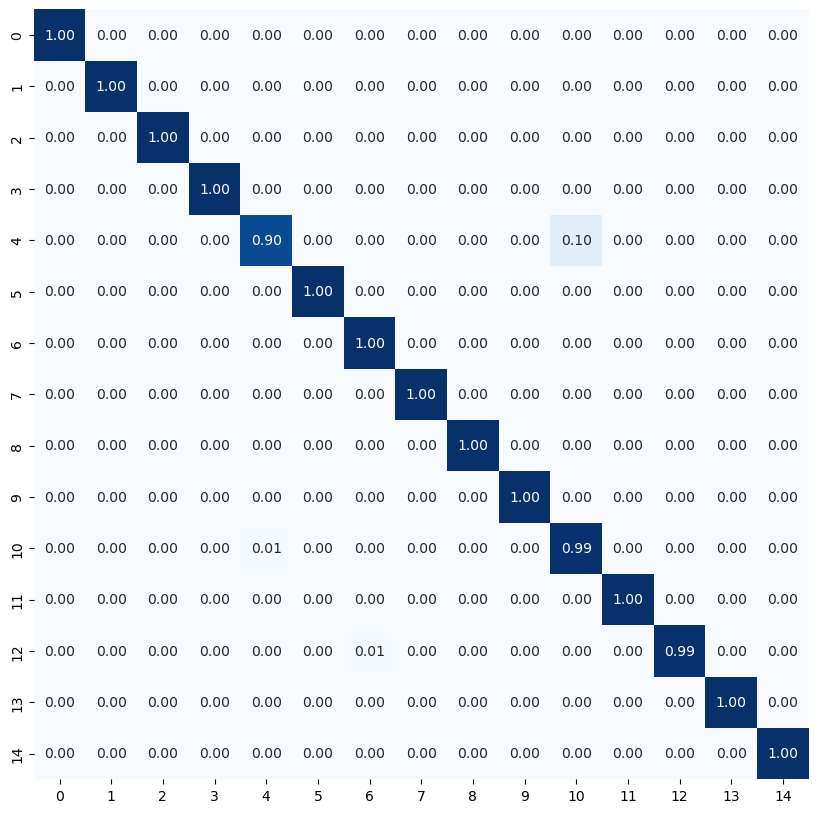

In [37]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


### Re-training the model with data augmentation to see if model robustness improved

In [38]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 871ms/step - accuracy: 0.1250 - loss: 33.3525 - val_accuracy: 0.0500 - val_loss: 3.7155
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step - accuracy: 0.5125 - loss: 33.2138 - val_accuracy: 0.5500 - val_loss: 2.9254
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 550ms/step - accuracy: 0.5625 - loss: 24.8727 - val_accuracy: 0.5500 - val_loss: 2.3393
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 510ms/step - accuracy: 0.4750 - loss: 13.9875 - val_accuracy: 0.5500 - val_loss: 1.9370
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step - accuracy: 0.6000 - loss: 4.8029 - val_accuracy: 0.5500 - val_loss: 1.6170
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.5500 - loss: 5.7697 - val_accuracy: 0.5500 - val_loss: 1.3986
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.6000 - loss: 3.5016 - val_accuracy: 0.5500 - val_loss: 1.2988
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.5750 - loss: 1.5940 - val_accuracy: 0.5500 - val_

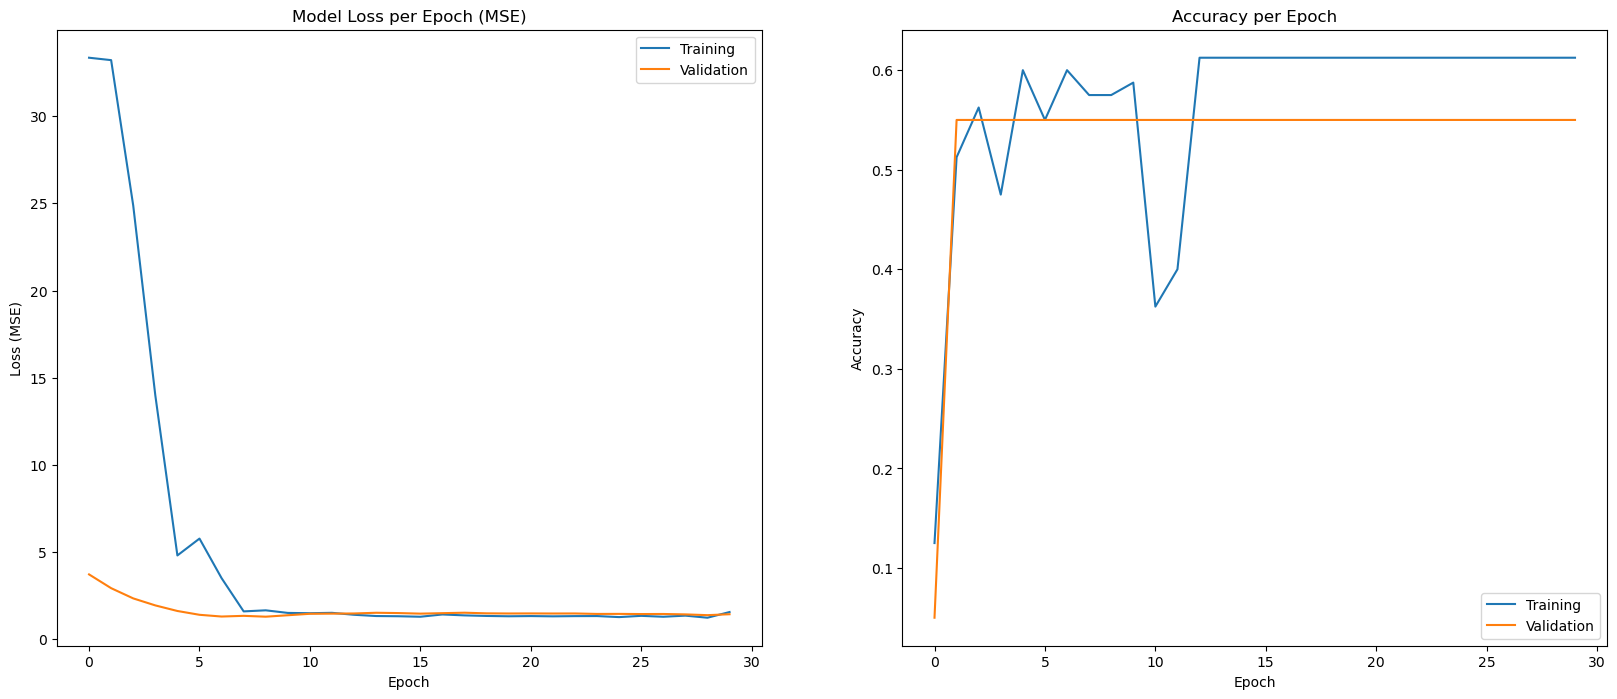

In [39]:
plot_training(model_history)


In [40]:
model.save('cnn_obj_classifier_data_aug.keras')
model.save_weights('cnn_obj_classifier_data_aug.weights.h5')


In [41]:
y_true, y_pred = get_predictions_and_labels(test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.00      0.00      0.00       150
           2       0.00      0.00      0.00       132
           3       0.08      1.00      0.14       117
           4       0.02      0.04      0.02        78
           5       0.00      0.00      0.00       110
           6       0.00      0.00      0.00       124
           7       0.00      0.00      0.00       115
           8       0.00      0.00      0.00       167
           9       0.00      0.00      0.00       160
          10       0.00      0.00      0.00       117
          11       0.00      0.00      0.00        42
          12       0.00      0.00      0.00       100
          13       0.00      0.00      0.00        79
          14       0.00      0.00      0.00       151

    accuracy                           0.07      1725
   macro avg       0.01      0.07      0.01      1725
weighted avg       0.01   

/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

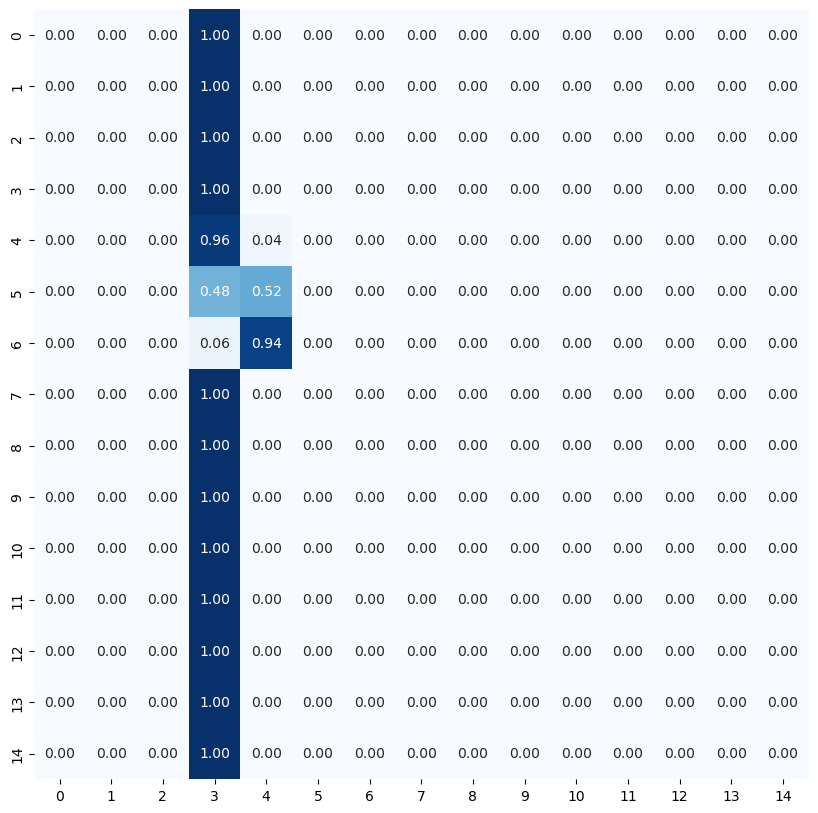

In [42]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


## CNN for multi-class anomaly classification

In [46]:
data_dir = "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies/transistor"  

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)


Found 100 files belonging to 5 classes.
Using 80 files for training.
Found 100 files belonging to 5 classes.
Using 20 files for validation.


In [48]:
anoms = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies/transistor/").iterdir() if p.is_dir()]

print('Anomaly type to label mapping:')
for label, obj in enumerate(anoms):
    print(f'{label}: {obj}')
    

Anomaly type to label mapping:
0: bent_lead
1: cut_lead
2: damaged_case
3: good
4: misplaced


In [49]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 700ms/step - accuracy: 0.4875 - loss: 1.6775 - val_accuracy: 0.6000 - val_loss: 1.5962
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.6500 - loss: 1.0791 - val_accuracy: 0.6000 - val_loss: 1.2445
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - accuracy: 0.6750 - loss: 0.8893 - val_accuracy: 0.6000 - val_loss: 1.1184
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.7750 - loss: 0.7509 - val_accuracy: 0.6000 - val_loss: 1.0515
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.7875 - loss: 0.6135 - val_accuracy: 0.5500 - val_loss: 1.3043
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.8000 - loss: 0.5619 - val_accuracy: 0.6000 - val_loss: 0.8768
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.8125 - loss: 0.4854 - val_accuracy: 0.6000 - val_loss: 0.9319
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.8250 - loss: 0.4460 - val_accuracy: 0.6000 - val_loss:

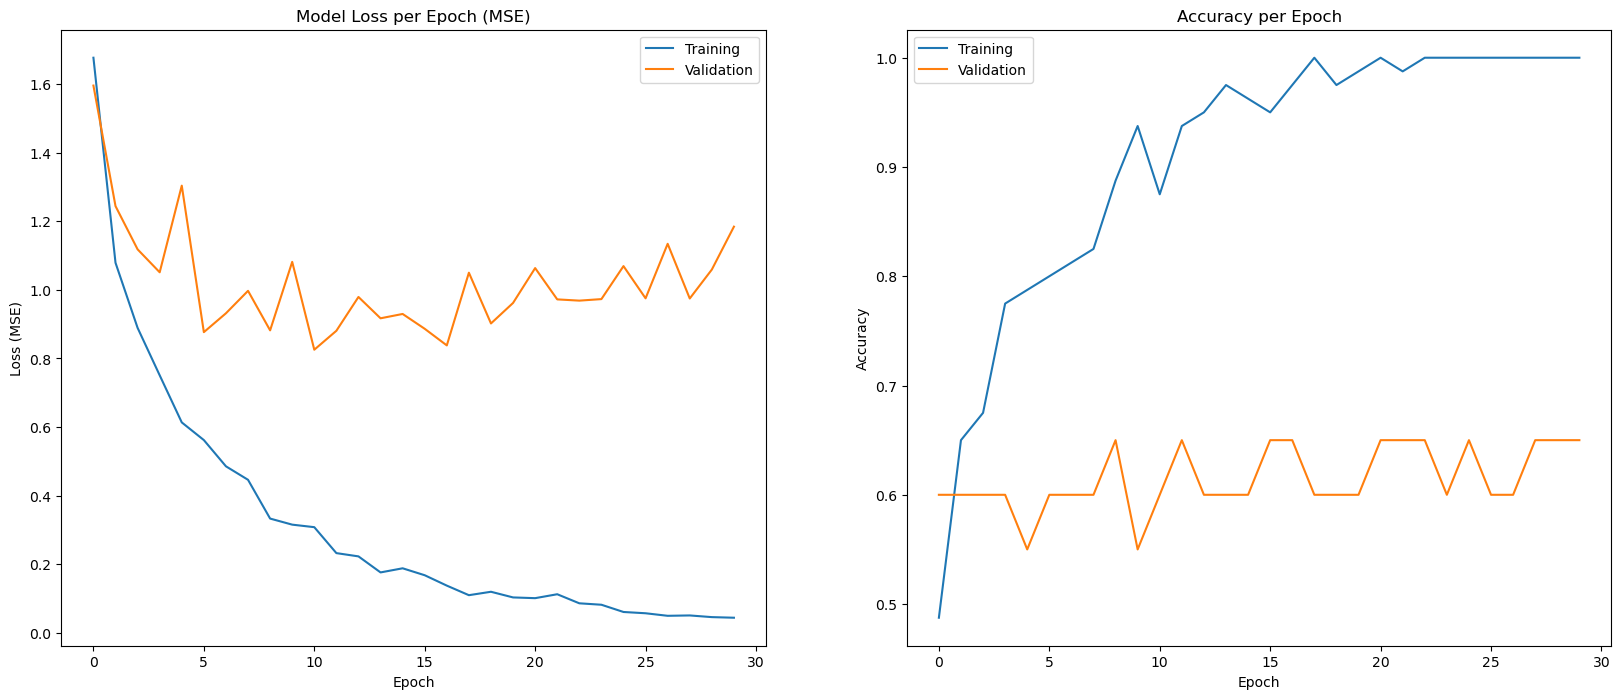

In [50]:
plot_training(model_history)


## Data augmentation for anomaly minority classes

In [18]:
# Augment all anomaly images for transistor

# Adapted from: https://pyimagesearch.com/2019/07/08/keras-imagedatagenerator-and-data-augmentation/

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img

imgs_to_gen = 7
root_dir = Path('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/all_anomalies')
output_dir = os.path.join(root_dir, 'augmented_imgs')

img_files = [f for f in root_dir.rglob('*.png') if f.is_file()]

for img_file in img_files:
    img_prefix = str(img_file).split('/')[-1].strip('.png')
    
    print(f"[INFO] loading image {img_prefix}.png...")
    image = load_img(img_file)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    
    # Construct the image generator for data augmentation then
    aug = ImageDataGenerator(
       rotation_range=15,       # rotate images by ±15 degrees
       width_shift_range=0.1,   # 10% horizontal shift
       height_shift_range=0.1,  # 10% vertical shift
       zoom_range=0.1,          # zoom in/out by 10%
       shear_range=0.1,         # apply shear transformation
       horizontal_flip=False,   # not needed
       fill_mode='nearest'      # fill missing pixels after transformations
    )

    # Initialize the total number of images generated thus far
    total = 0
    
    # Construct the actual Python generator
    print(f"[INFO] generating {imgs_to_gen} augmented images...")
    imageGen = aug.flow(image, batch_size=1, save_to_dir=output_dir,
    	save_prefix=img_prefix, save_format="png")
    # Loop over examples from our image data augmentation generator
    for image in imageGen:
    	# increment our counter
    	total += 1
    	# If we have reached the specified number of examples, break from the loop
    	if total == imgs_to_gen:
    		break


[INFO] loading image bent_lead_000.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_001.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_002.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_003.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_004.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_005.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_006.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_007.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_008.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_009.png...
[INFO] generating 7 augmented images...
[INFO] loading image cut_lead_000.png...
[INFO] generating 7 augmented images...
[INFO] loading image cut_lead_001.png...
[INFO] generating 7 augmented images...
[INFO] loading ima

In [28]:
print('After augmentation, total transistor dataset is 320 (280 augmented + 40 original) images with anomalies and 273 without.\n')
print('A holdout test dataset will be pre-split (this will contain a mixture of good as well as original and augmented anomaly images taking care not to only include augmented versions of originals used for training).')


After augmentation, total transistor dataset is 320 (280 augmented + 40 original) images with anomalies and 273 without.

A holdout test dataset will be pre-split (this will contain a mixture of good as well as original and augmented anomaly images taking care not to only include augmented versions of originals used for training).


In [29]:
# Set up training with augmented data

# 'good' test and train data combined for transistor
# 7 augmented images made for each transistor anomaly image
# 50 random images are taken from 'good' and 'anomaly' classes to make the holdout test set

augmented_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/pre_split/train'
holdout_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/pre_split/holdout'

train_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=24,
    batch_size=16,
)  


Found 493 files belonging to 2 classes.
Using 395 files for training.
Found 493 files belonging to 2 classes.
Using 98 files for validation.
Found 100 files belonging to 2 classes.


In [30]:
cats = [p.name for p in Path(augmented_dir).iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: all_anomalies


In [31]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


Epoch 1/30


2026-01-27 11:13:31.263041: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-27 11:13:31.645652: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-27 11:13:31.787865: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19668992 exceeds 10% of free system memory.
2026-01-27 11:13:32.048731: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-27 11:13:32.329186: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19668992 exceeds 10% of free system memory.


25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 553ms/step - accuracy: 0.7797 - loss: 0.4887 - val_accuracy: 0.9490 - val_loss: 0.1426
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - accuracy: 0.9342 - loss: 0.2063 - val_accuracy: 0.9490 - val_loss: 0.1555
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 298ms/step - accuracy: 0.9494 - loss: 0.1529 - val_accuracy: 0.9592 - val_loss: 0.1427
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.9595 - loss: 0.1123 - val_accuracy: 0.9592 - val_loss: 0.1378
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.9722 - loss: 0.0905 - val_accuracy: 0.9592 - val_loss: 0.1400
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.9696 - loss: 0.0898 - val_accuracy: 0.9388 - val_loss: 0.1916
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step - accuracy: 0.9747 - loss: 0.0721 - val_accuracy: 0.9694 - val_loss: 0.1326
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.9823 - loss: 0.0551 - val_accuracy: 0.9592 - val

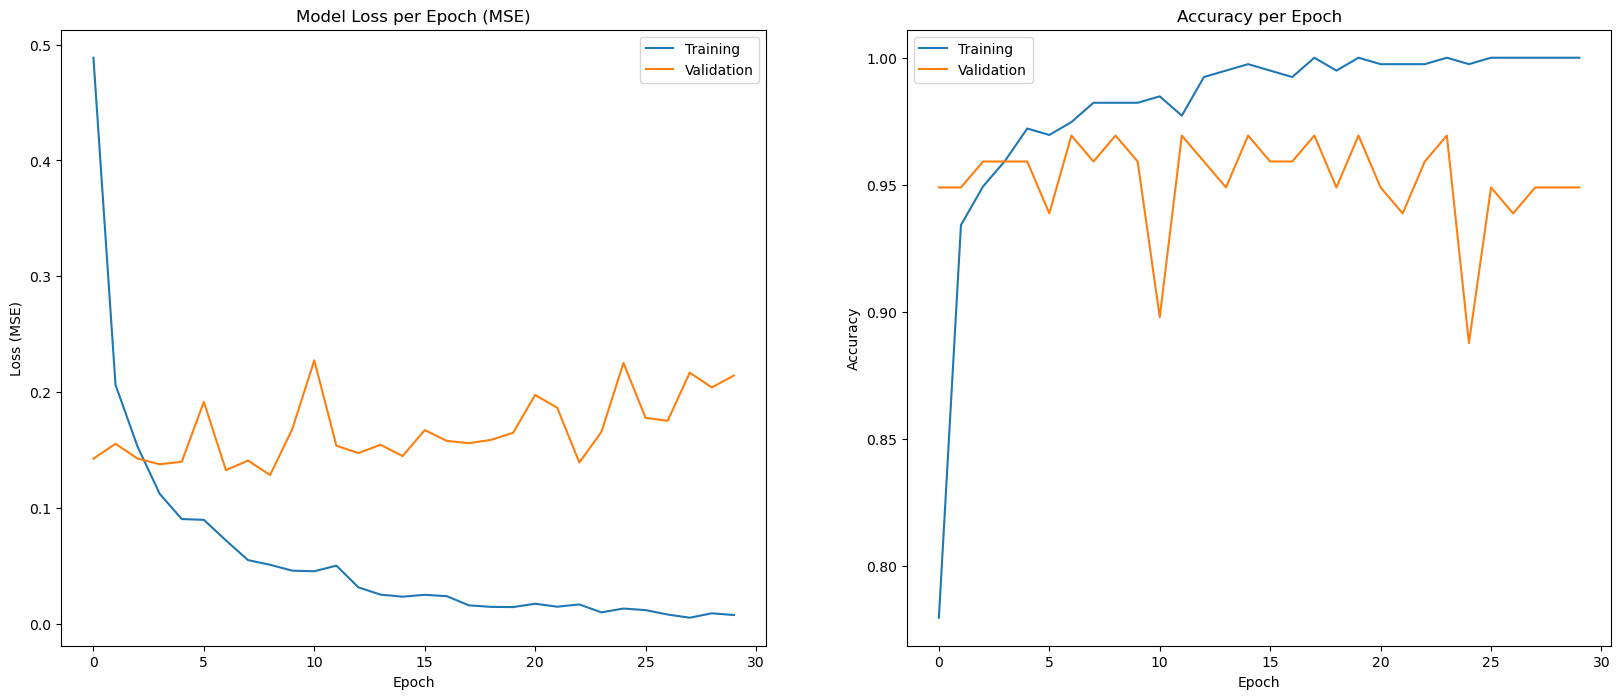

In [32]:
plot_training(model_history)


In [33]:
y_true, y_pred = get_predictions_and_labels(test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.49      0.92      0.64        50
           1       0.43      0.06      0.11        50

    accuracy                           0.49       100
   macro avg       0.46      0.49      0.37       100
weighted avg       0.46      0.49      0.37       100



2026-01-27 11:21:28.455927: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


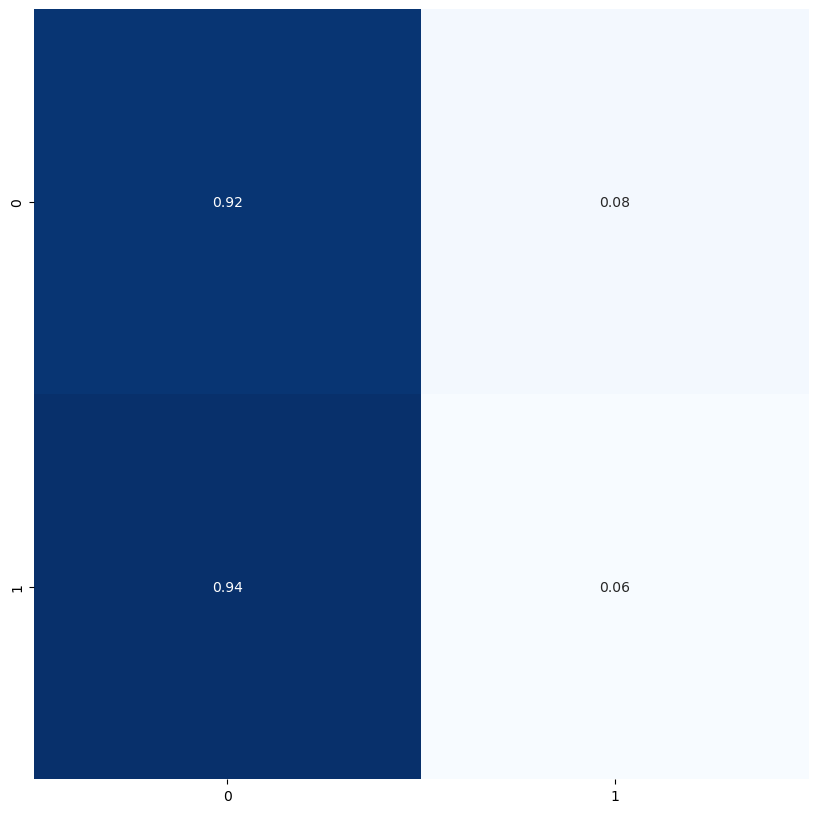

In [34]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


## CNN for binary anomaly classification

In [35]:
data_dir = "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/transistor"  

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)


Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.


In [36]:
cats = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/transistor").iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: all_anomalies


In [37]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 441ms/step - accuracy: 0.9000 - loss: 0.3798 - val_accuracy: 0.5500 - val_loss: 1.5373
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step - accuracy: 0.8250 - loss: 0.6860 - val_accuracy: 0.8500 - val_loss: 0.3322
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - accuracy: 0.9000 - loss: 0.2507 - val_accuracy: 0.9000 - val_loss: 0.2890
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.9625 - loss: 0.2146 - val_accuracy: 0.9500 - val_loss: 0.2835
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.9500 - loss: 0.1787 - val_accuracy: 0.9000 - val_loss: 0.2428
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.9625 - loss: 0.1445 - val_accuracy: 0.9500 - val_loss: 0.2472
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.9500 - loss: 0.1156 - val_accuracy: 0.9000 - val_loss: 0.2475
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.9750 - loss: 0.0958 - val_accuracy: 0.9000 - val_loss:

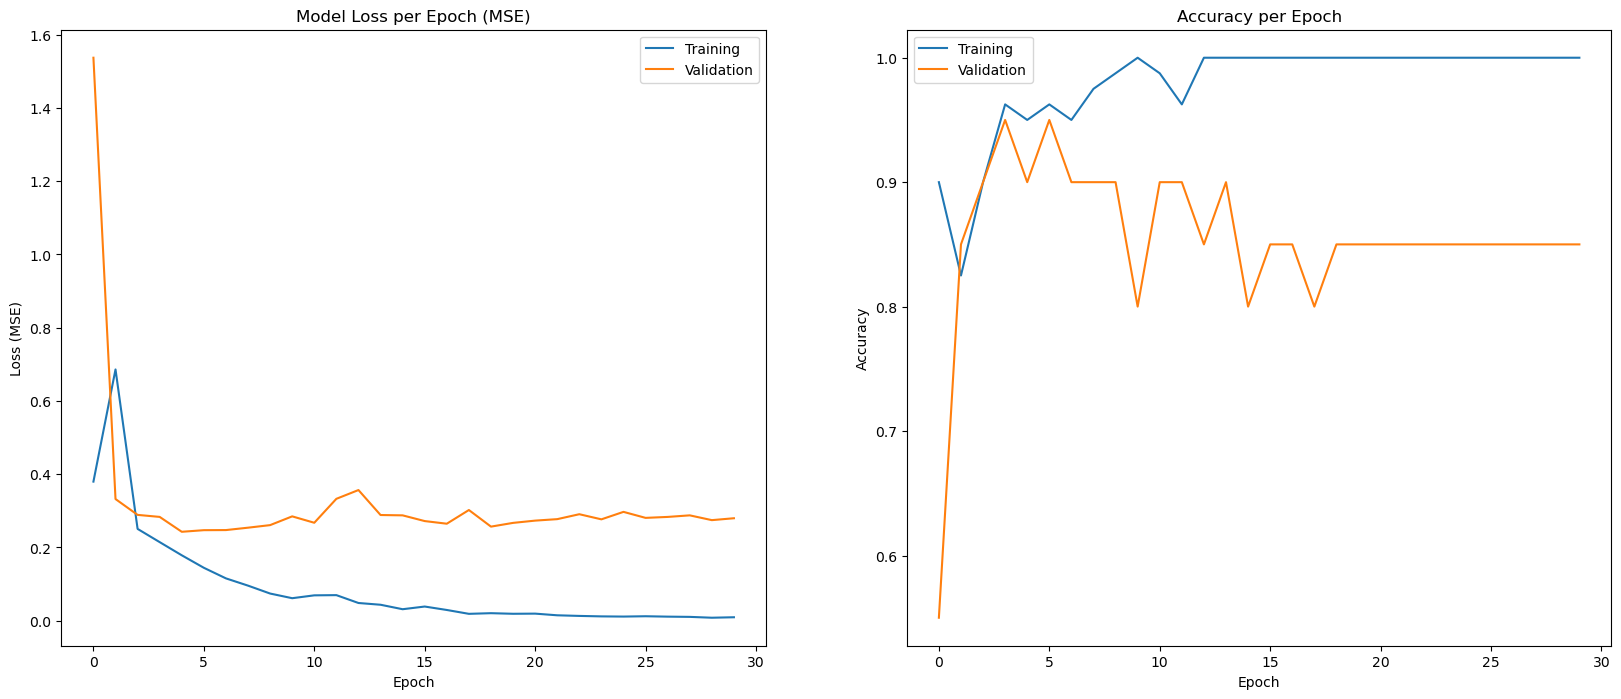

In [38]:
plot_training(model_history)


In [39]:
y_true, y_pred = get_predictions_and_labels(test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.49      0.96      0.65        50
           1       0.00      0.00      0.00        50

    accuracy                           0.48       100
   macro avg       0.24      0.48      0.32       100
weighted avg       0.24      0.48      0.32       100



2026-01-27 11:28:58.803004: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


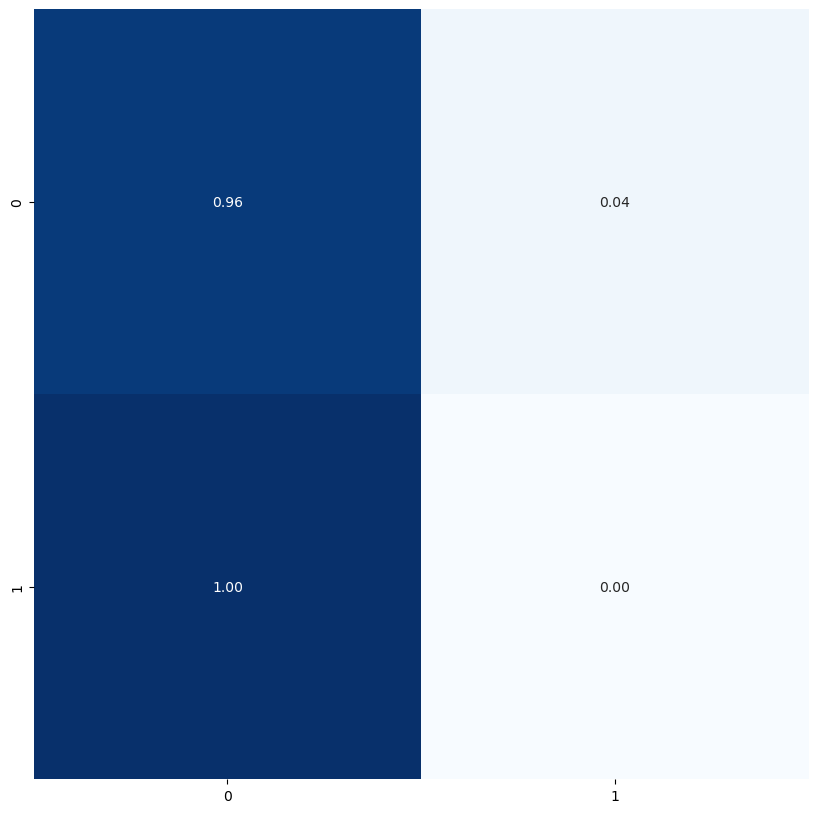

In [40]:
# Display the confusion matrix

plot_cm(y_true, y_pred)
